# Project: Plant Disease Classification

## 1. Data Loading & Preprocessing

### a. Importing Essential Libraries
First, we import our core libraries and the custom helper functions we created in `src/utils.py`.

In [1]:
import sys
import os

# Add the project's root directory to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import tensorflow as tf
import matplotlib.pyplot as plt
from src.utils import load_and_split_data, plot_batch, count_samples, build_model, plot_history, plot_confusion_matrix

### b. Defining Core Parameters and Constants
We set up our main parameters as constants. This makes the code cleaner and allows for easy adjustments.

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = '../data'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')

### c. Loading and Splitting the Datasets
We now call our custom function from `utils.py` to handle all the data loading and splitting logic.

In [3]:
training_set, validation_set, test_set, class_names = load_and_split_data(
    train_dir=TRAIN_DIR,
    val_dir=VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)
print(f"Class names found: {class_names}")

Found 2953 files belonging to 6 classes.
Found 1446 files belonging to 6 classes.
Class names found: ['Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Tomato___healthy']


### d. Implementing Data Augmentation
Data augmentation is a powerful technique to prevent overfitting. We create a sequential model with random transformations that will be applied **only** to the training data during the training process.

In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

### e. Building the Final Optimized Data Pipeline
We apply our augmentation layer to the training set and add performance optimizations (`.cache()` and `.prefetch()`) to all datasets. This ensures our GPU doesn't have to wait for data during training.

In [5]:
training_set = training_set.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

training_set = training_set.prefetch(buffer_size=tf.data.AUTOTUNE)
validation_set = validation_set.prefetch(buffer_size=tf.data.AUTOTUNE)
test_set = test_set.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Data pipelines built and optimized successfully.")

Data pipelines built and optimized successfully.


### f. Visualizing a Batch of Augmented Data
Finally, we use our second utility function to visualize a batch of images from our `training_set`. This confirms that our data loading and augmentation are working as expected.

2025-07-31 12:03:12.992896: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


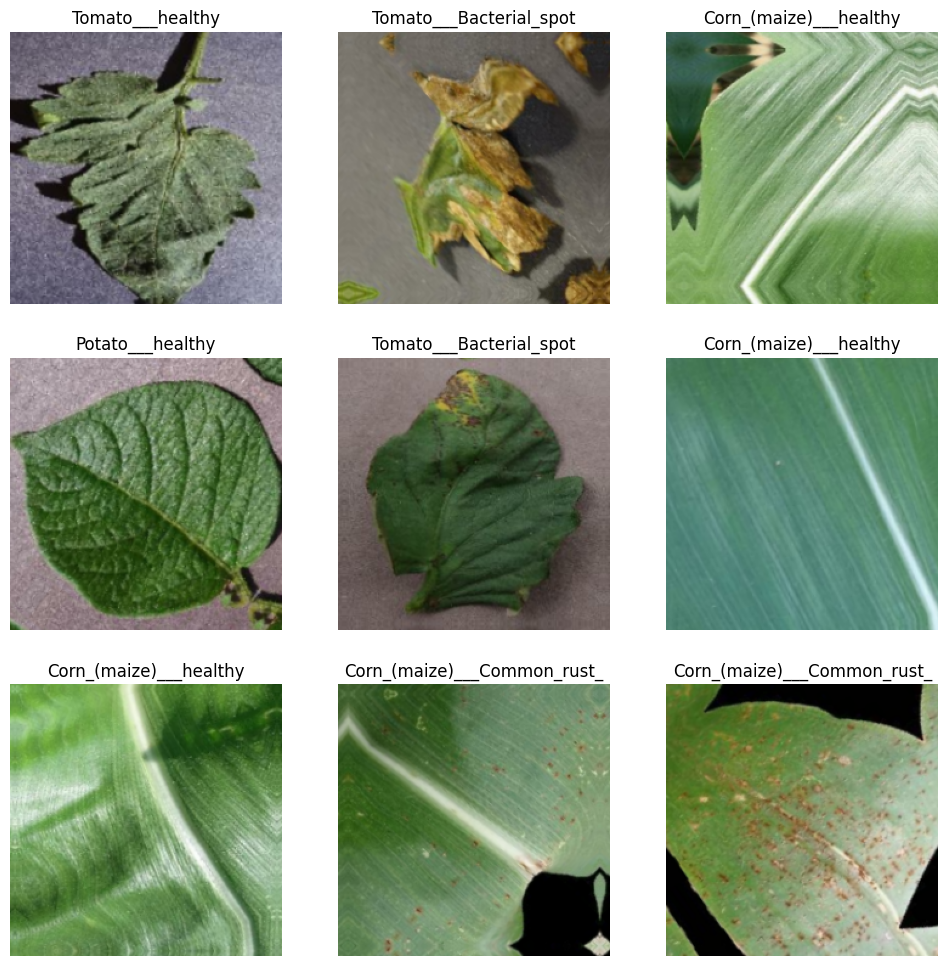

In [6]:
plot_batch(training_set, class_names)

### g. Exploring Class Distribution
Before we build the model, let's analyze the distribution of images across our different classes. We'll use our helper function from `utils.py` to get the counts. This helps us identify any potential class imbalance.



2025-07-31 12:03:15.672418: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training set distribution:
 {'Corn_(maize)___Common_rust_': 474, 'Corn_(maize)___healthy': 465, 'Potato___Early_blight': 400, 'Potato___healthy': 121, 'Tomato___Bacterial_spot': 851, 'Tomato___healthy': 642}

Validation set distribution:
 {'Corn_(maize)___Common_rust_': 239, 'Corn_(maize)___healthy': 233, 'Potato___Early_blight': 200, 'Potato___healthy': 31, 'Tomato___Bacterial_spot': 33, 'Tomato___healthy': 0}


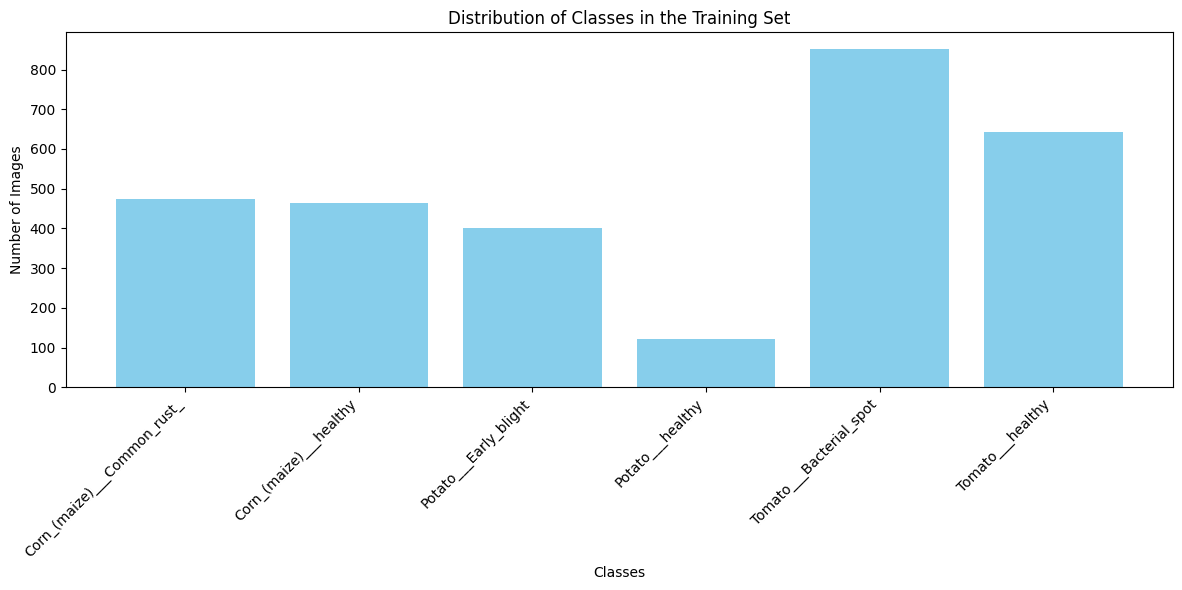

In [7]:
train_counts = count_samples(training_set, class_names)
val_counts = count_samples(validation_set, class_names)

print(f"Training set distribution:\n {train_counts}")
print(f"\nValidation set distribution:\n {val_counts}")

# Visualize the training set distribution
plt.figure(figsize=(12, 6))
plt.bar(train_counts.keys(), train_counts.values(), color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Distribution of Classes in the Training Set")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation of the Plot**

This chart clearly shows that your training dataset is **imbalanced**.

- **Dominant Classes:** `The Tomato___Bacterial_spot` and `Tomato___healthy` classes have significantly more images than the others.

- **Underrepresented Class:** `The Potato___healthy` class is severely underrepresented, with far fewer samples than any other category.

**What This Means for Our Model:**

- **Model Bias:** The model will see many more examples of tomato diseases. It might become biased towards predicting these majority classes and may not learn the features of the underrepresented classes effectively. Metrics-wise, a high overall accuracy can be misleading. For example, a model that's great at identifying tomatoes but terrible at identifying healthy potatoes might still seem accurate overall. Therefore, we will need to pay close attention to metrics like **Precision**, **Recall**, and the **Confusion Matrix** to understand the true performance for each specific class.

## 2. Building and Training the Model
### 2.1 Model Building and Compilation
Now we'll build our classification model. We'll use **transfer learning**, a technique where we adapt a model pre-trained on a large dataset (ImageNet) for our specific task. This approach helps achieve high accuracy with less data and faster training.

We're using **MobileNetV2** as our base model because it's lightweight, fast, and provides excellent performance. We'll load the model without its final classification layer (`include_top=False`) and "freeze" its weights by setting `base_model.trainable = False.` This ensures that only our new, custom layers will be trained initially.

We'll call our helper function from `utils.py`, which encapsulates all the logic for creating the MobileNetV2 transfer learning architecture and compiling it with the appropriate optimizer, loss function, and metrics.

In [8]:
model = build_model(num_classes=len(class_names))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 2.2 Implement Early Stopping
To prevent overfitting and save training time, we'll use an `EarlyStopping` callback. This will monitor the validation loss (`val_loss`) and stop training if performance stops improving.

In [9]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### 2.3 Train the Model
Now, we train the model using `.fit()`. We pass our training and validation sets and include the `early_stopping` callback. The results are stored in a `history` object.

In [10]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=50,
    callbacks=[early_stopping]
)

Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 23s 225ms/step - accuracy: 0.7099 - loss: 0.8507 - precision: 0.8189 - recall: 0.5804 - val_accuracy: 0.9837 - val_loss: 0.1067 - val_precision: 0.9877 - val_recall: 0.9783
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - accuracy: 0.9779 - loss: 0.1041 - precision: 0.9819 - recall: 0.9706 - val_accuracy: 0.9932 - val_loss: 0.0534 - val_precision: 0.9932 - val_recall: 0.9905
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - accuracy: 0.9868 - loss: 0.0633 - precision: 0.9907 - recall: 0.9838 - val_accuracy: 0.9932 - val_loss: 0.0488 - val_precision: 0.9946 - val_recall: 0.9932
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 24s 254ms/step - accuracy: 0.9933 - loss: 0.0440 - precision: 0.9950 - recall: 0.9920 - val_accuracy: 0.9959 - val_loss: 0.0344 - val_precision: 0.9959 - val_recall: 0.9959
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 25s 267ms/step - accuracy: 0.9929 - loss: 0.0357 - precision: 0.9937 - recall: 0.9910 - val_accuracy: 0.9959 - val_los